In [2]:

import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

from src.data.fetch import fetch_stock_data
from src.indicators.pipeline import compute_all_indicators

# ══════════════════════════════════════════════════════════════════
# SETUP — fetch and compute once, reuse across all exercises
# ══════════════════════════════════════════════════════════════════

In [3]:

print("Fetching and computing indicators for RELIANCE.NS...")
raw_2y = fetch_stock_data("RELIANCE.NS", period="2y", save=True)
df     = compute_all_indicators(raw_2y)

print(f"Total rows after indicator warm-up: {len(df)}")
print(f"Columns available: {list(df.columns)}\n")


Fetching and computing indicators for RELIANCE.NS...
Fetching RELIANCE.NS  (2y)...
Downloaded 499 trading days
Range : 2024-07-03 -> 2026-07-03
Latest Close : ₹1,304.00
Saved to C:\Users\devgi\InvestIQ\notebooks\..\data\raw\RELIANCE_NS_2y.csv
Total rows after indicator warm-up: 450
Columns available: ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20', 'RSI', 'RSI_Signal', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Pct', 'Volume_Ratio', 'ATR', 'ATR_Pct']




# ══════════════════════════════════════════════════════════════════
# EXERCISE 1
# Run compute_all_indicators and interpret every column of
# the last row in plain English
# ══════════════════════════════════════════════════════════════════


In [4]:

print("=" * 60)
print("EXERCISE 1 — Interpret today's indicator values")
print("=" * 60)

last_row  = df.iloc[-1]     # most recent trading day
last_date = df.index[-1]

print(f"\nDate: {last_date.date()}")
print(f"{'─' * 60}")


def interpret_rsi(rsi_val):
    if rsi_val > 70:
        return f"RSI = {rsi_val:.1f} — OVERBOUGHT. Stock has risen sharply recently. Potential reversal risk."
    elif rsi_val > 60:
        return f"RSI = {rsi_val:.1f} — Approaching overbought. Bullish momentum but getting stretched."
    elif rsi_val > 40:
        return f"RSI = {rsi_val:.1f} — NEUTRAL zone. No strong signal either way."
    elif rsi_val > 30:
        return f"RSI = {rsi_val:.1f} — Approaching oversold. Mild bearish pressure."
    else:
        return f"RSI = {rsi_val:.1f} — OVERSOLD. Stock has fallen sharply. Potential bounce candidate."


def interpret_macd(macd_val, signal_val, hist_val):
    crossover = "BULLISH crossover (MACD above Signal)" if macd_val > signal_val \
                else "BEARISH crossover (MACD below Signal)"
    momentum  = "ACCELERATING (histogram growing)" if hist_val > 0 \
                else "DECELERATING (histogram shrinking/negative)"
    return f"MACD = {macd_val:.3f}, Signal = {signal_val:.3f} — {crossover}. Momentum: {momentum}"


def interpret_bb(close, bb_upper, bb_lower, bb_pct, bb_width):
    if bb_pct > 1.0:
        zone = "ABOVE upper band — strongly overbought on volatility basis"
    elif bb_pct > 0.8:
        zone = "Near UPPER band — price elevated, watch for pullback"
    elif bb_pct > 0.2:
        zone = "MIDDLE of bands — no extreme volatility signal"
    elif bb_pct > 0.0:
        zone = "Near LOWER band — price depressed, watch for bounce"
    else:
        zone = "BELOW lower band — strongly oversold on volatility basis"

    squeeze = "SQUEEZE (bands very tight — big move brewing)" if bb_width < 0.05 \
              else "Normal band width"
    return (f"BB%B = {bb_pct:.2f} — {zone}. "
            f"Band width = {bb_width:.3f} — {squeeze}.")


def interpret_ma(close, sma20, sma50, ema20):
    trend_short = "above" if close > sma20 else "below"
    trend_long  = "above" if close > sma50 else "below"
    ma_cross    = "GOLDEN CROSS setup (SMA20 > SMA50 — bullish)" if sma20 > sma50 \
                  else "DEATH CROSS setup (SMA20 < SMA50 — bearish)"
    return (f"Price ₹{close:.2f} is {trend_short} SMA20 (₹{sma20:.2f}) "
            f"and {trend_long} SMA50 (₹{sma50:.2f}). {ma_cross}.")


def interpret_volume(vol_ratio):
    if vol_ratio > 3.0:
        return f"Volume ratio = {vol_ratio:.2f}x — EXTREMELY high. Major institutional activity likely."
    elif vol_ratio > 2.0:
        return f"Volume ratio = {vol_ratio:.2f}x — Very high volume. Strong conviction in today's move."
    elif vol_ratio > 1.2:
        return f"Volume ratio = {vol_ratio:.2f}x — Above average. Moderate conviction."
    elif vol_ratio > 0.8:
        return f"Volume ratio = {vol_ratio:.2f}x — Normal volume. No unusual activity."
    else:
        return f"Volume ratio = {vol_ratio:.2f}x — Below average. Low conviction — weak signal day."


def interpret_atr(atr_val, atr_pct):
    if atr_pct > 3.0:
        volatility = "HIGH volatility"
    elif atr_pct > 1.5:
        volatility = "MODERATE volatility"
    else:
        volatility = "LOW volatility"
    return (f"ATR = ₹{atr_val:.2f} ({atr_pct:.2f}% of price) — {volatility}. "
            f"Expect ~₹{atr_val:.0f} daily price swing on average.")


EXERCISE 1 — Interpret today's indicator values

Date: 2026-07-03
────────────────────────────────────────────────────────────


In [5]:
# Print full interpretation
print("\n📊 PRICE & MOVING AVERAGES")
print(interpret_ma(
    last_row["Close"], last_row["SMA_20"],
    last_row["SMA_50"], last_row["EMA_20"]
))

print("\n📈 RSI (Momentum)")
print(interpret_rsi(last_row["RSI"]))

print("\n📉 MACD (Trend + Momentum)")
print(interpret_macd(
    last_row["MACD"],
    last_row["MACD_Signal"],
    last_row["MACD_Hist"]
))

print("\n🎯 BOLLINGER BANDS (Volatility)")
print(interpret_bb(
    last_row["Close"],   last_row["BB_Upper"],
    last_row["BB_Lower"],last_row["BB_Pct"],
    last_row["BB_Width"]
))

print("\n📦 VOLUME")
print(interpret_volume(last_row["Volume_Ratio"]))

print("\n💨 ATR (Volatility)")
print(interpret_atr(last_row["ATR"], last_row["ATR_Pct"]))

# Overall signal summary
bullish_signals = 0
bearish_signals = 0

if last_row["RSI"] < 50:         bearish_signals += 1
else:                             bullish_signals += 1
if last_row["MACD"] > last_row["MACD_Signal"]: bullish_signals += 1
else:                             bearish_signals += 1
if last_row["Close"] > last_row["SMA_50"]:     bullish_signals += 1
else:                             bearish_signals += 1
if last_row["BB_Pct"] < 0.5:     bearish_signals += 1
else:                             bullish_signals += 1

print(f"\n{'─' * 60}")
print(f"OVERALL: {bullish_signals} bullish signals, "
      f"{bearish_signals} bearish signals out of 4 indicators")
bias = "BULLISH BIAS" if bullish_signals > bearish_signals else \
       "BEARISH BIAS" if bearish_signals > bullish_signals else "NEUTRAL"
print(f"→ {bias}")




📊 PRICE & MOVING AVERAGES
Price ₹1304.00 is above SMA20 (₹1302.48) and below SMA50 (₹1339.27). DEATH CROSS setup (SMA20 < SMA50 — bearish).

📈 RSI (Momentum)
RSI = 46.3 — NEUTRAL zone. No strong signal either way.

📉 MACD (Trend + Momentum)
MACD = -6.051, Signal = -7.326 — BULLISH crossover (MACD above Signal). Momentum: ACCELERATING (histogram growing)

🎯 BOLLINGER BANDS (Volatility)
BB%B = 0.52 — MIDDLE of bands — no extreme volatility signal. Band width = 0.070 — Normal band width.

📦 VOLUME
Volume ratio = 0.54x — Below average. Low conviction — weak signal day.

💨 ATR (Volatility)
ATR = ₹18.80 (1.44% of price) — LOW volatility. Expect ~₹19 daily price swing on average.

────────────────────────────────────────────────────────────
OVERALL: 2 bullish signals, 2 bearish signals out of 4 indicators
→ NEUTRAL


# ══════════════════════════════════════════════════════════════════
# EXERCISE 2
# Find all RSI < 30 (oversold) dates in last 2 years
# Check price 10 trading days later — did the stock recover?
# ══════════════════════════════════════════════════════════════════


EXERCISE 2 — RSI Oversold Backtest

Total oversold days (RSI < 30) in 2 years: 22

Analysed 22 oversold signals (excluded last 10 days — no future data)

────────────────────────────────────────────────────────────
      date  rsi  entry_price  exit_price  return_10d  recovered
2024-10-04 29.6      1374.65     1347.66       -1.96      False
2024-10-07 27.5      1358.99     1357.48       -0.11      False
2024-10-15 28.0      1332.52     1328.53       -0.30      False
2024-10-25 29.5      1316.48     1272.76       -3.32      False
2024-11-04 28.9      1291.00     1231.02       -4.65      False
2024-11-11 28.4      1261.80     1282.13        1.61       True
2024-11-12 29.0      1263.34     1259.92       -0.27      False
2024-11-13 25.6      1241.33     1281.14        3.21       True
2024-11-19 27.4      1231.02     1297.74        5.42       True
2024-11-21 24.8      1212.53     1310.73        8.10       True
2025-03-03 29.3      1161.22     1228.24        5.77       True
2025-03-04 27.5 

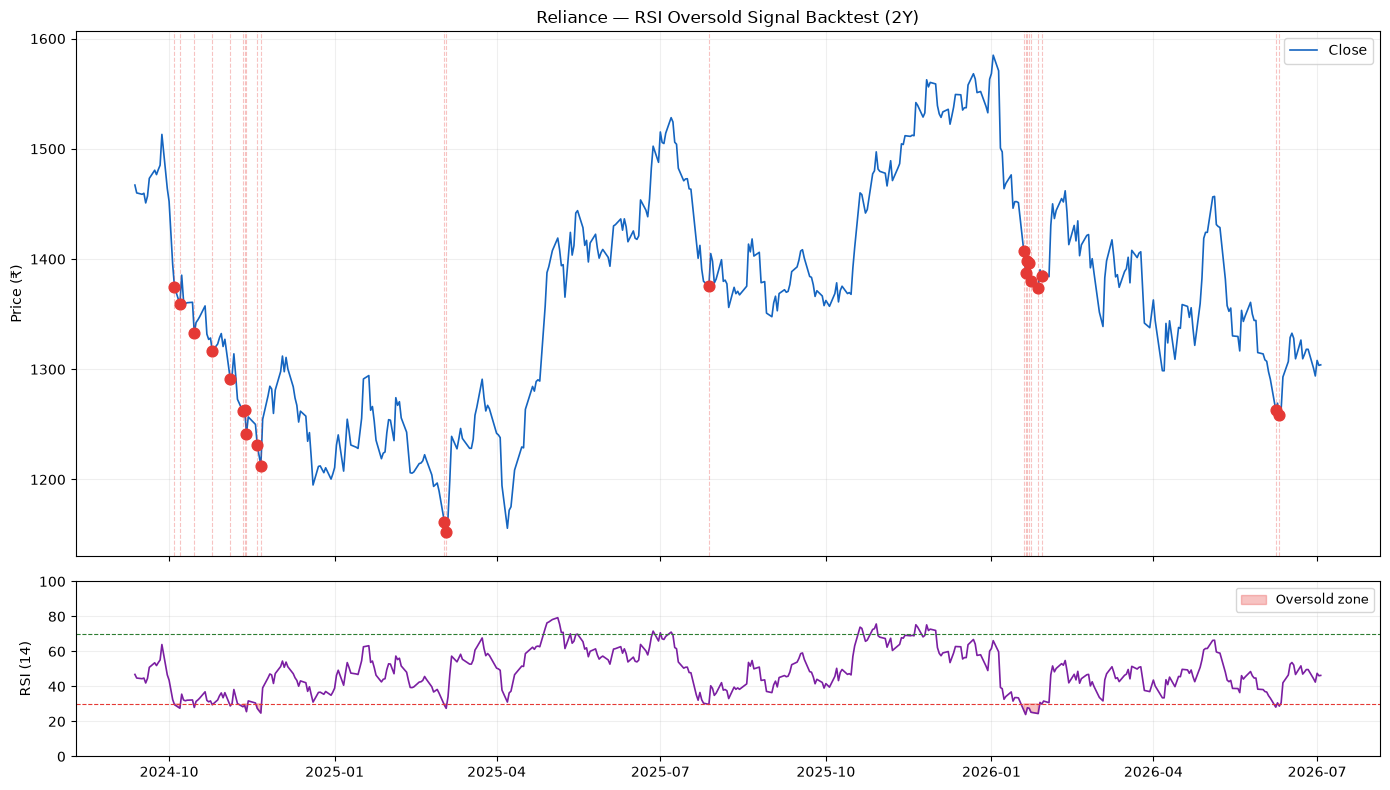


Chart saved to data/charts/rsi_backtest.png


In [6]:
print("\n" + "=" * 60)
print("EXERCISE 2 — RSI Oversold Backtest")
print("=" * 60)

# Find all days where RSI dropped below 30
oversold_dates = df[df["RSI"] < 30].index
print(f"\nTotal oversold days (RSI < 30) in 2 years: {len(oversold_dates)}")

if len(oversold_dates) == 0:
    print("No oversold days found. Try a longer period or lower threshold.")
else:
    results = []

    for date in oversold_dates:
        # Find the integer position of this date in the DataFrame
        pos = df.index.get_loc(date)

        # Check if there are at least 10 rows after this date
        # (can't look 10 days forward if we're near the end of data)
        if pos + 10 >= len(df):
            continue

        entry_price  = df["Close"].iloc[pos]        # price on oversold day
        exit_price   = df["Close"].iloc[pos + 10]   # price 10 days later
        rsi_on_day   = df["RSI"].iloc[pos]

        # Return over the next 10 trading days
        return_10d = (exit_price - entry_price) / entry_price * 100

        results.append({
            "date"        : date.date(),
            "rsi"         : round(rsi_on_day, 1),
            "entry_price" : round(entry_price, 2),
            "exit_price"  : round(exit_price, 2),
            "return_10d"  : round(return_10d, 2),
            "recovered"   : return_10d > 0
        })

    results_df = pd.DataFrame(results)

    print(f"\nAnalysed {len(results_df)} oversold signals "
          f"(excluded last 10 days — no future data)")
    print(f"\n{'─' * 60}")
    print(results_df.to_string(index=False))

    # Summary statistics
    avg_return    = results_df["return_10d"].mean()
    median_return = results_df["return_10d"].median()
    win_rate      = results_df["recovered"].mean() * 100
    best_case     = results_df["return_10d"].max()
    worst_case    = results_df["return_10d"].min()

    print(f"\n{'─' * 60}")
    print(f"BACKTEST SUMMARY — 10 days after RSI < 30:")
    print(f"  Signals analysed : {len(results_df)}")
    print(f"  Win rate         : {win_rate:.1f}% of signals led to recovery")
    print(f"  Average return   : {avg_return:+.2f}%")
    print(f"  Median return    : {median_return:+.2f}%")
    print(f"  Best case        : {best_case:+.2f}%")
    print(f"  Worst case       : {worst_case:+.2f}%")

    # Interpretation
    print(f"\nINTERPRETATION:")
    if win_rate > 60 and avg_return > 0:
        print(f"  RSI oversold signal is EFFECTIVE for RELIANCE.NS.")
        print(f"  Stock recovered {win_rate:.0f}% of the time within 10 days,")
        print(f"  averaging a {avg_return:.1f}% gain. The signal has real predictive value.")
    elif win_rate > 50:
        print(f"  RSI oversold signal shows MILD effectiveness.")
        print(f"  Stock recovered {win_rate:.0f}% of the time — slightly better than a coin flip.")
        print(f"  Not reliable alone — needs confirmation from other signals.")
    else:
        print(f"  RSI oversold signal is WEAK for this stock/period.")
        print(f"  Only {win_rate:.0f}% recovery rate — oversold can stay oversold.")
        print(f"  This is why we combine multiple indicators in the ML model.")

    # Plot the backtest signals on a price chart
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                    gridspec_kw={"height_ratios": [3, 1]},
                                    sharex=True)

    ax1.plot(df.index, df["Close"], color="#1565C0", lw=1.2, label="Close")

    # Mark oversold entry points on price chart
    for _, row in results_df.iterrows():
        entry_date = pd.Timestamp(row["date"])
        if entry_date in df.index:
            ax1.axvline(entry_date, color="#E53935",
                        alpha=0.3, lw=0.8, linestyle="--")
            ax1.scatter(entry_date, row["entry_price"],
                        color="#E53935", s=60, zorder=5)

    ax1.set_title("Reliance — RSI Oversold Signal Backtest (2Y)", fontsize=12)
    ax1.set_ylabel("Price (₹)")
    ax1.legend()
    ax1.grid(alpha=0.2)

    ax2.plot(df.index, df["RSI"], color="#7B1FA2", lw=1.2)
    ax2.axhline(30, color="#E53935", linestyle="--", lw=0.8)
    ax2.axhline(70, color="#2E7D32", linestyle="--", lw=0.8)
    ax2.fill_between(df.index, df["RSI"], 30,
                      where=(df["RSI"] <= 30),
                      color="#E53935", alpha=0.3, label="Oversold zone")
    ax2.set_ylabel("RSI (14)")
    ax2.set_ylim(0, 100)
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig("../data/charts/rsi_backtest.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nChart saved to data/charts/rsi_backtest.png")




# ══════════════════════════════════════════════════════════════════
# EXERCISE 3
# ATR verification — confirm it was added to the pipeline
# and interpret the values
# ══════════════════════════════════════════════════════════════════



EXERCISE 3 — ATR Verification and Analysis

ATR column exists in DataFrame: True
ATR_Pct column exists         : True

ATR statistics over 2 years:
  Current ATR    : ₹18.80 (1.44% of price)
  Average ATR    : ₹25.17
  Highest ATR    : ₹39.95 on 2026-04-06 — most volatile period
  Lowest ATR     : ₹14.93 on 2025-09-19 — calmest period


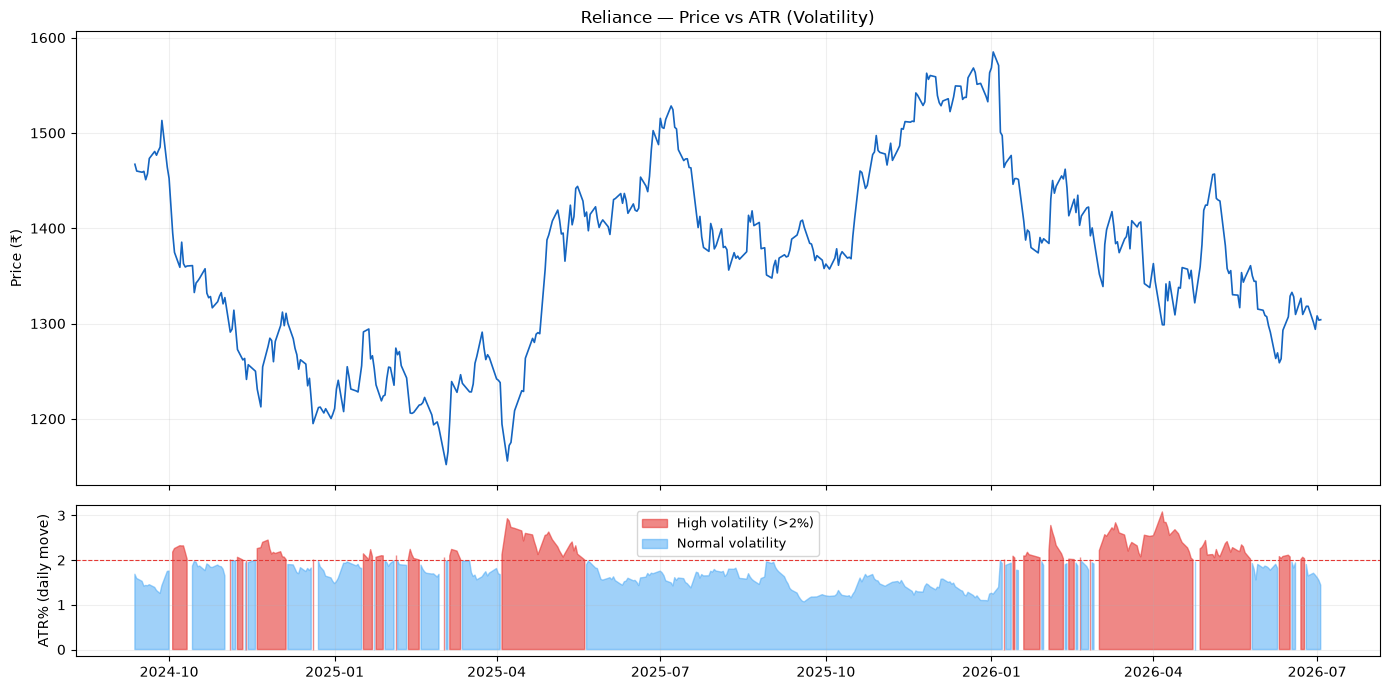

Chart saved to data/charts/atr_analysis.png

Why ATR matters for the ML model (Week 5):
  ATR tells us the expected daily move.
  A stock with ATR = 2% needs to move more than 2%
  to be 'significant'. Our 5-day prediction horizon
  is more reliable when ATR is low — less noise.
  High ATR periods = noisy signal, model less reliable.


In [7]:

print("\n" + "=" * 60)
print("EXERCISE 3 — ATR Verification and Analysis")
print("=" * 60)

# ATR is already in df because we updated compute_all_indicators()
print(f"\nATR column exists in DataFrame: {'ATR' in df.columns}")
print(f"ATR_Pct column exists         : {'ATR_Pct' in df.columns}")

print(f"\nATR statistics over 2 years:")
print(f"  Current ATR    : ₹{df['ATR'].iloc[-1]:.2f} "
      f"({df['ATR_Pct'].iloc[-1]:.2f}% of price)")
print(f"  Average ATR    : ₹{df['ATR'].mean():.2f}")
print(f"  Highest ATR    : ₹{df['ATR'].max():.2f} "
      f"on {df['ATR'].idxmax().date()} — most volatile period")
print(f"  Lowest ATR     : ₹{df['ATR'].min():.2f} "
      f"on {df['ATR'].idxmin().date()} — calmest period")

# Plot ATR alongside price to see volatility regimes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7),
                                gridspec_kw={"height_ratios": [3, 1]},
                                sharex=True)

ax1.plot(df.index, df["Close"], color="#1565C0", lw=1.2)
ax1.set_title("Reliance — Price vs ATR (Volatility)", fontsize=12)
ax1.set_ylabel("Price (₹)")
ax1.grid(alpha=0.2)

# Colour ATR by volatility level
ax2.fill_between(df.index, df["ATR_Pct"], 0,
                  where=(df["ATR_Pct"] > 2.0),
                  color="#E53935", alpha=0.6, label="High volatility (>2%)")
ax2.fill_between(df.index, df["ATR_Pct"], 0,
                  where=(df["ATR_Pct"] <= 2.0),
                  color="#42A5F5", alpha=0.5, label="Normal volatility")
ax2.axhline(2.0, color="#E53935", lw=0.8, linestyle="--")
ax2.set_ylabel("ATR% (daily move)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../data/charts/atr_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to data/charts/atr_analysis.png")

# Key insight about ATR for the ML model
print(f"\nWhy ATR matters for the ML model (Week 5):")
print(f"  ATR tells us the expected daily move.")
print(f"  A stock with ATR = 2% needs to move more than 2%")
print(f"  to be 'significant'. Our 5-day prediction horizon")
print(f"  is more reliable when ATR is low — less noise.")
print(f"  High ATR periods = noisy signal, model less reliable.")



# ══════════════════════════════════════════════════════════════════
# EXERCISE 4
# Signal summary card for the most recent trading day
# This becomes the "Today's Signals" panel in the frontend
# ══════════════════════════════════════════════════════════════════


EXERCISE 4 — Today's Signal Summary Card


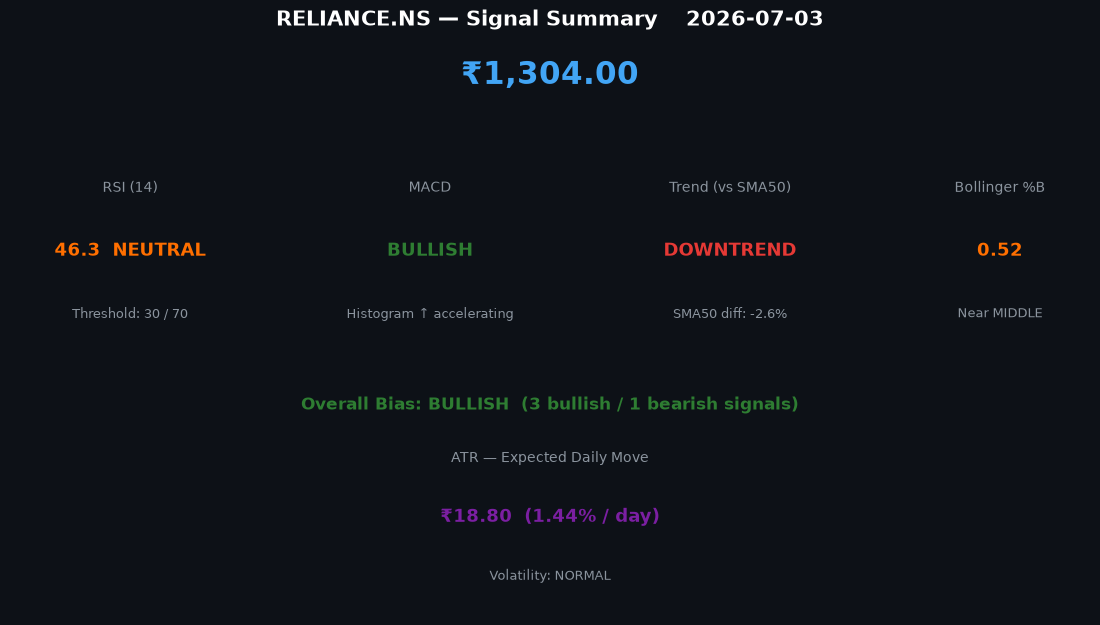


Signal card saved to data/charts/signal_card.png

────────────────────────────────────────────────────────────
TEXT VERSION — what the API will return:
────────────────────────────────────────────────────────────
  ticker      : RELIANCE.NS
  date        : 2026-07-03
  close       : ₹1,304.00
  rsi         : 46.3 (NEUTRAL)
  macd        : BULLISH (↑ accelerating)
  trend       : DOWNTREND (-2.6% from SMA50)
  bollinger   : %B = 0.52 (near MIDDLE)
  atr         : ₹18.80 (1.44%/day)
  overall     : BULLISH (3/4 bullish)
────────────────────────────────────────────────────────────

Week 2 exercises complete.
This text output is exactly what FastAPI will serve
to the frontend in Week 10.


In [8]:

print("\n" + "=" * 60)
print("EXERCISE 4 — Today's Signal Summary Card")
print("=" * 60)

last = df.iloc[-1]
date = df.index[-1].date()

# ── Compute signal values ──────────────────────────────────────────

# RSI signal
rsi_val    = last["RSI"]
rsi_signal_label = (
    "OVERBOUGHT"  if rsi_val > 70 else
    "OVERSOLD"    if rsi_val < 30 else
    "NEUTRAL"
)
rsi_color  = "#E53935" if rsi_val > 70 else "#2E7D32" if rsi_val < 30 else "#FF6F00"

# MACD signal
macd_cross = "BULLISH" if last["MACD"] > last["MACD_Signal"] else "BEARISH"
macd_color = "#2E7D32" if macd_cross == "BULLISH" else "#E53935"
hist_trend = "↑ accelerating" if last["MACD_Hist"] > 0 else "↓ decelerating"

# Trend signal
above_sma50  = last["Close"] > last["SMA_50"]
trend_label  = "UPTREND" if above_sma50 else "DOWNTREND"
trend_color  = "#2E7D32" if above_sma50 else "#E53935"
sma50_diff   = ((last["Close"] - last["SMA_50"]) / last["SMA_50"]) * 100

# Bollinger signal
bb_pct_val  = last["BB_Pct"]
bb_label    = (
    "UPPER BAND"  if bb_pct_val > 0.8 else
    "LOWER BAND"  if bb_pct_val < 0.2 else
    "MIDDLE"
)
bb_color    = "#E53935" if bb_pct_val > 0.8 else "#2E7D32" if bb_pct_val < 0.2 else "#FF6F00"
squeeze     = last["BB_Width"] < df["BB_Width"].quantile(0.2)

# ── Build the visual card ──────────────────────────────────────────
fig = plt.figure(figsize=(12, 7))
fig.patch.set_facecolor("#0D1117")    # dark background

title = fig.text(
    0.5, 0.93,
    f"RELIANCE.NS — Signal Summary    {date}",
    ha="center", va="center",
    fontsize=15, fontweight="bold", color="white"
)

price_text = fig.text(
    0.5, 0.85,
    f"₹{last['Close']:,.2f}",
    ha="center", va="center",
    fontsize=22, fontweight="bold", color="#42A5F5"
)

# Helper to draw each signal box
def draw_signal_box(fig, x, y, w, h, title, value, detail, color):
    ax = fig.add_axes([x, y, w, h])
    ax.set_facecolor("#161B22")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Border
    for spine in ["top", "bottom", "left", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(color)
        ax.spines[spine].set_linewidth(2)

    ax.text(0.5, 0.80, title,  ha="center", va="center",
            fontsize=10, color="#8B949E")
    ax.text(0.5, 0.50, value,  ha="center", va="center",
            fontsize=13, fontweight="bold", color=color)
    ax.text(0.5, 0.20, detail, ha="center", va="center",
            fontsize=9,  color="#8B949E")


# Draw 4 signal boxes
draw_signal_box(
    fig, 0.05, 0.45, 0.20, 0.30,
    "RSI (14)",
    f"{rsi_val:.1f}  {rsi_signal_label}",
    f"Threshold: 30 / 70",
    rsi_color
)

draw_signal_box(
    fig, 0.30, 0.45, 0.20, 0.30,
    "MACD",
    f"{macd_cross}",
    f"Histogram {hist_trend}",
    macd_color
)

draw_signal_box(
    fig, 0.55, 0.45, 0.20, 0.30,
    "Trend (vs SMA50)",
    f"{trend_label}",
    f"SMA50 diff: {sma50_diff:+.1f}%",
    trend_color
)

draw_signal_box(
    fig, 0.80, 0.45, 0.15, 0.30,
    "Bollinger %B",
    f"{bb_pct_val:.2f}",
    f"Near {bb_label}" + ("\n⚡ SQUEEZE" if squeeze else ""),
    bb_color
)

# ATR box at the bottom
draw_signal_box(
    fig, 0.30, 0.08, 0.40, 0.28,
    "ATR — Expected Daily Move",
    f"₹{last['ATR']:.2f}  ({last['ATR_Pct']:.2f}% / day)",
    f"Volatility: {'HIGH' if last['ATR_Pct'] > 2 else 'NORMAL'}",
    "#7B1FA2"
)

# Count signals
total_bullish = sum([
    rsi_val < 50,
    macd_cross == "BULLISH",
    above_sma50,
    bb_pct_val > 0.5
])
total_bearish = 4 - total_bullish
bias_label    = "BULLISH" if total_bullish > total_bearish else \
                "BEARISH" if total_bearish > total_bullish else "NEUTRAL"
bias_color    = "#2E7D32" if bias_label == "BULLISH" else \
                "#E53935" if bias_label == "BEARISH" else "#FF6F00"

fig.text(
    0.5, 0.38,
    f"Overall Bias: {bias_label}  "
    f"({total_bullish} bullish / {total_bearish} bearish signals)",
    ha="center", va="center",
    fontsize=12, fontweight="bold", color=bias_color
)

plt.savefig(
    "../data/charts/signal_card.png",
    dpi=150, bbox_inches="tight",
    facecolor="#0D1117"
)
plt.show()
print(f"\nSignal card saved to data/charts/signal_card.png")

# Also print a clean text version (for the API response in Week 10)
print(f"\n{'─' * 60}")
print(f"TEXT VERSION — what the API will return:")
print(f"{'─' * 60}")
print(f"  ticker      : RELIANCE.NS")
print(f"  date        : {date}")
print(f"  close       : ₹{last['Close']:,.2f}")
print(f"  rsi         : {rsi_val:.1f} ({rsi_signal_label})")
print(f"  macd        : {macd_cross} ({hist_trend})")
print(f"  trend       : {trend_label} ({sma50_diff:+.1f}% from SMA50)")
print(f"  bollinger   : %B = {bb_pct_val:.2f} (near {bb_label})")
print(f"  atr         : ₹{last['ATR']:.2f} ({last['ATR_Pct']:.2f}%/day)")
print(f"  overall     : {bias_label} ({total_bullish}/4 bullish)")
print(f"{'─' * 60}")
print(f"\nWeek 2 exercises complete.")
print(f"This text output is exactly what FastAPI will serve")
print(f"to the frontend in Week 10.")